In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw
from collections import Counter

In [5]:
df = pd.read_csv("mol_datasets/mol_energies.csv")
df.head()

,SMILES,ERE,HRE
0,FC=1C(F)=C(F)C2=CC3=C(SC4=C3SC5=CC=6C=CC=CC6C=...,0.21,0.13
1,S1C=2C=CC=3C=CC=CC3C2C=4SC=5C=CC=6C=CC=CC6C5C14,0.21,0.20
2,S1C2=CC(=CC=C2C=3SC=4C=C(C=CC4C13)CCCCCCCC)CCC...,0.29,0.25
3,S1C=C2C=C3SC4=CC=CC=C4C3=CC2=C1,0.22,0.11
4,S1C=CC=2C=C3C=C4C=CSC4=CC3=CC12,0.21,0.11


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 434 entries, 0 to 433
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SMILES  434 non-null    object 
 1   ERE     434 non-null    float64
 2   HRE     434 non-null    float64
dtypes: float64(2), object(1)
memory usage: 10.3+ KB


Number of atoms: 28


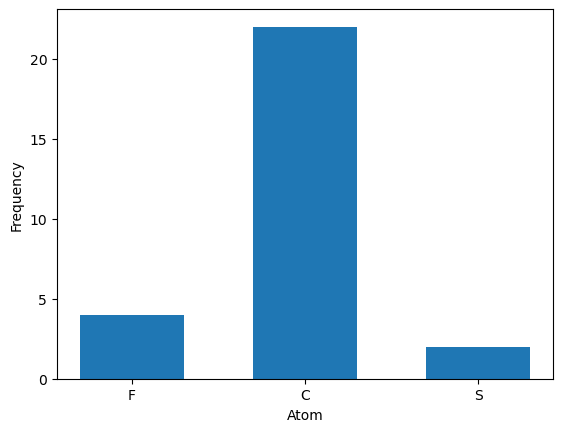

In [ ]:
smiles = "FC=1C(F)=C(F)C2=CC3=C(SC4=C3SC5=CC=6C=CC=CC6C=C54)C=C2C1F"

mol = Chem.MolFromSmiles(smiles)
num_atoms = mol.GetNumAtoms()
print("Number of atoms:", num_atoms)

atom_list = []
for atom in mol.GetAtoms():
    atom_list.append(atom.GetSymbol())
    
counts = Counter(atom_list)

labels = list(counts.keys())
values = list(counts.values())

plt.bar(labels, values, align='center', width=0.6)
plt.xlabel("Atom")
plt.ylabel("Frequency")
plt.show()

(7, 0, 2)


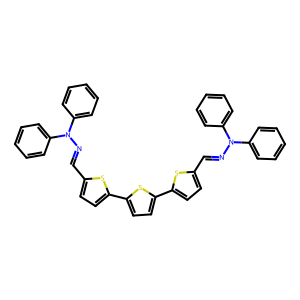

In [136]:
def ring_summary(smiles: str):
    mol = Chem.MolFromSmiles(smiles)
    ri = mol.GetRingInfo()
    rings = [set(r) for r in ri.AtomRings()]
    fused_count = 0
    bridged_bonds = set()
    bond_rings = [set(r) for r in ri.BondRings()]

    for i in range(len(rings)):
        for j in range(i + 1, len(rings)):
            shared = rings[i] & rings[j]
            if len(shared) == 2:
                fused_count += 1
            for bond in mol.GetBonds():
                a1, a2 = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
                if ((a1 in rings[i] and a2 in rings[j]) or
                    (a2 in rings[i] and a1 in rings[j])):
                    if not (a1 in shared or a2 in shared):
                        # skip aromatic or ring bonds
                        if bond.GetIsAromatic():
                            continue
                        if any(bond.GetIdx() in br for br in bond_rings):
                            continue
                        bridged_bonds.add(tuple(sorted((a1, a2))))

    return len(rings), fused_count, len(bridged_bonds)

# Example usage
smiles = "N(=CC=1SC(=CC1)C=2SC(=CC2)C=3SC(C=NN(C=4C=CC=CC4)C=5C=CC=CC5)=CC3)N(C=6C=CC=CC6)C=7C=CC=CC7"
mol = Chem.MolFromSmiles(smiles)

# Draw the molecule
img = Draw.MolsToGridImage([mol], molsPerRow=1, subImgSize=(300,300))
print(ring_summary(smiles))
img

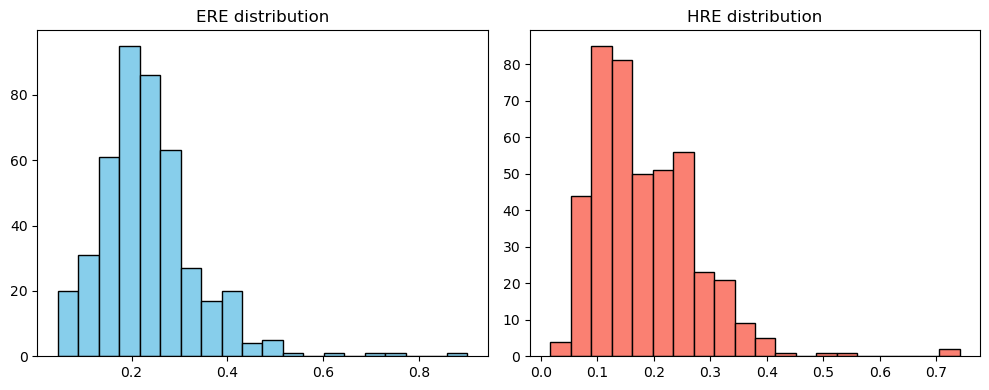

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(df["ERE"], bins=20, color="skyblue", edgecolor="black")
axes[0].set_title("ERE distribution")

axes[1].hist(df["HRE"], bins=20, color="salmon", edgecolor="black")
axes[1].set_title("HRE distribution")
plt.tight_layout()
plt.show()

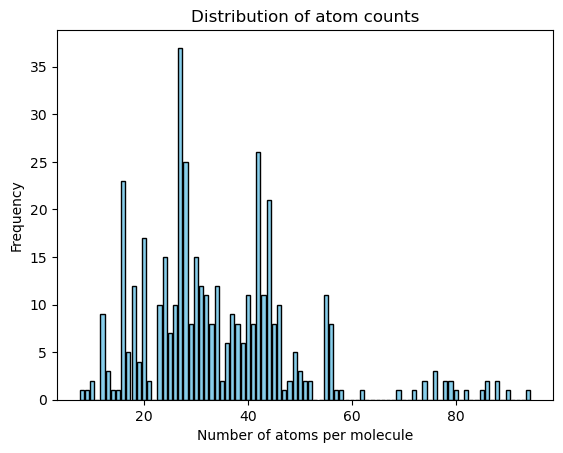

In [89]:
atom_counts = []
for smi in df['SMILES'].values:
    mol = Chem.MolFromSmiles(smi)
    if mol:  # ensure SMILES is valid
        atom_counts.append(mol.GetNumAtoms())

# Plot histogram of atom counts
plt.hist(atom_counts, bins=np.arange(min(atom_counts), max(atom_counts)+2)-0.5,
         edgecolor="black", color="skyblue", rwidth=0.8)
plt.xlabel("Number of atoms per molecule")
plt.ylabel("Frequency")
plt.title("Distribution of atom counts")
plt.show()

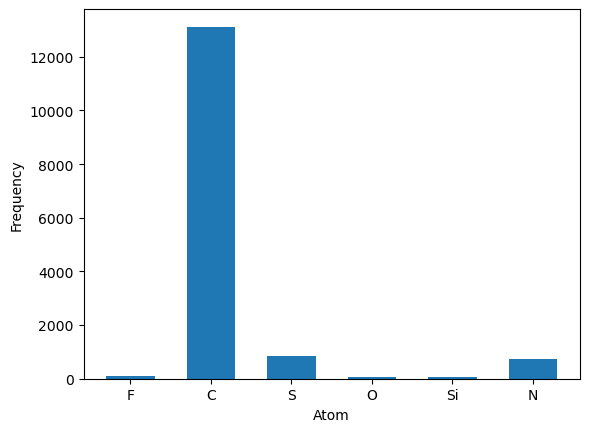

In [90]:
all_atoms = []
for smi in df['SMILES'].values:
    mol = Chem.MolFromSmiles(smi)
    if mol:  
        for atom in mol.GetAtoms():
            all_atoms.append(atom.GetSymbol())

counts = Counter(all_atoms)
labels = list(counts.keys())
values = list(counts.values())
plt.bar(labels, values, align='center', width=0.6)
plt.xlabel("Atom")
plt.ylabel("Frequency")
plt.show()

Add new features

In [7]:
def heteroatom_counts(smiles):
    """
    Count heteroatoms (F, S, O, Si, N) in a molecule.
    Returns a dictionary with counts.
    """
    mol = Chem.MolFromSmiles(smiles)
    atom_list = [atom.GetSymbol() for atom in mol.GetAtoms()]
    counts = Counter(atom_list)
    result = {elem: counts.get(elem, 0) for elem in ["F", "S", "O", "Si", "N"]}
    return result # mol.GetNumAtoms()

smiles = "S1C=2C=CC=CC2C=3C=C4C(=CC13)C=C(C5=C[SiH2]C=C45)C6=CC=CC6"
print("Heteroatom counts:", heteroatom_counts(smiles))

Heteroatom counts: {'F': 0, 'S': 1, 'O': 0, 'Si': 1, 'N': 0}


In [137]:
for idx, row in df.iterrows():
    smiles = row['SMILES']
    rings, fused, bridged = ring_summary(smiles)
    het = heteroatom_counts(smiles)
    df.at[idx, "rings"] = rings
    df.at[idx, "fused"] = fused
    df.at[idx, "bridged"] = bridged
    df.at[idx, "F"] = het["F"]
    df.at[idx, "S"] = het["S"]
    df.at[idx, "O"] = het["O"]
    df.at[idx, "Si"] = het["Si"]
    df.at[idx, "N"] = het["N"]

df.head()

,SMILES,ERE,HRE,rings,fused,bridged,F,S,O,Si,N
0,FC=1C(F)=C(F)C2=CC3=C(SC4=C3SC5=CC=6C=CC=CC6C=...,0.21,0.13,6.0,5.0,0.0,4.0,2.0,0.0,0.0,0.0
1,S1C=2C=CC=3C=CC=CC3C2C=4SC=5C=CC=6C=CC=CC6C5C14,0.21,0.20,6.0,5.0,0.0,0.0,2.0,0.0,0.0,0.0
2,S1C2=CC(=CC=C2C=3SC=4C=C(C=CC4C13)CCCCCCCC)CCC...,0.29,0.25,4.0,3.0,0.0,0.0,2.0,0.0,0.0,0.0
3,S1C=C2C=C3SC4=CC=CC=C4C3=CC2=C1,0.22,0.11,4.0,3.0,0.0,0.0,2.0,0.0,0.0,0.0
4,S1C=CC=2C=C3C=C4C=CSC4=CC3=CC12,0.21,0.11,4.0,3.0,0.0,0.0,2.0,0.0,0.0,0.0


In [138]:
cols = ['ERE', 'HRE', 'rings', 'fused', 'bridged', 'F', 'S', 'O', 'Si', 'N']
df[cols]

,ERE,HRE,rings,fused,bridged,F,S,O,Si,N
0,0.210000,0.130000,6.0,5.0,0.0,4.0,2.0,0.0,0.0,0.0
1,0.210000,0.200000,6.0,5.0,0.0,0.0,2.0,0.0,0.0,0.0
2,0.290000,0.250000,4.0,3.0,0.0,0.0,2.0,0.0,0.0,0.0
3,0.220000,0.110000,4.0,3.0,0.0,0.0,2.0,0.0,0.0,0.0
4,0.210000,0.110000,4.0,3.0,0.0,0.0,2.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
429,0.507348,0.145094,21.0,24.0,0.0,0.0,0.0,0.0,0.0,4.0
430,0.546234,0.153272,25.0,28.0,0.0,0.0,0.0,0.0,0.0,4.0
431,0.110986,0.164684,23.0,26.0,0.0,0.0,2.0,0.0,0.0,2.0
432,0.126838,0.360667,23.0,24.0,0.0,0.0,2.0,0.0,0.0,2.0


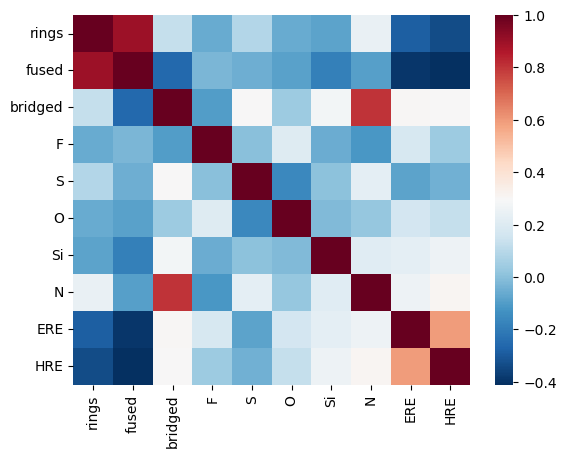

In [139]:
cols = ['rings', 'fused', 'bridged', 'F', 'S', 'O', 'Si', 'N', 'ERE', 'HRE']
df_corr = df[cols].corr()
sns.heatmap(df_corr, annot=False, cmap='RdBu_r')
plt.show()

In [140]:
df_corr

,rings,fused,bridged,F,S,O,Si,N,ERE,HRE
rings,1.000000,0.899895,0.127386,-0.060706,0.090074,-0.062845,-0.082038,0.239738,-0.290020,-0.334776
fused,0.899895,1.000000,-0.258510,-0.028421,-0.050111,-0.087348,-0.186060,-0.093069,-0.389991,-0.411305
bridged,0.127386,-0.258510,1.000000,-0.100896,0.299351,0.035824,0.277377,0.805976,0.300388,0.298561
F,-0.060706,-0.028421,-0.100896,1.000000,-0.002159,0.202993,-0.057544,-0.115786,0.175541,0.039440
S,0.090074,-0.050111,0.299351,-0.002159,1.000000,-0.159771,0.002751,0.222802,-0.082929,-0.044090
O,-0.062845,-0.087348,0.035824,0.202993,-0.159771,1.000000,-0.019472,0.021845,0.165080,0.126896
Si,-0.082038,-0.186060,0.277377,-0.057544,0.002751,-0.019472,1.000000,0.208733,0.225074,0.260106
N,0.239738,-0.093069,0.805976,-0.115786,0.222802,0.021845,0.208733,1.000000,0.256557,0.309312
ERE,-0.290020,-0.389991,0.300388,0.175541,-0.082929,0.165080,0.225074,0.256557,1.000000,0.592584
HRE,-0.334776,-0.411305,0.298561,0.039440,-0.044090,0.126896,0.260106,0.309312,0.592584,1.000000


Use of S as a heteroatom is a reasonable choice to lower ERE and HRE

In [141]:
corr_pairs = df_corr.unstack()
corr_pairs = corr_pairs.drop(labels=[(col, col) for col in df_corr.columns])
corr_df = corr_pairs.reset_index()
corr_df.columns = ["Feature1", "Feature2", "Correlation"]
corr_df[["Feature1", "Feature2"]] = pd.DataFrame(
    np.sort(corr_df[["Feature1", "Feature2"]].values, axis=1),
    index=corr_df.index
)
corr_df = corr_df.drop_duplicates(subset=["Feature1", "Feature2"])
high_corr = corr_df[abs(corr_df["Correlation"]) >= 0.3] \
    .sort_values(by="Correlation", ascending=False)
high_corr.reset_index(drop=True)

,Feature1,Feature2,Correlation
0,fused,rings,0.899895
1,N,bridged,0.805976
2,ERE,HRE,0.592584
3,HRE,N,0.309312
4,ERE,bridged,0.300388
5,HRE,rings,-0.334776
6,ERE,fused,-0.389991
7,HRE,fused,-0.411305


<ul>
  <li>ERE and HRE have a strong positive correlation</li>
  <li>N atom tends to increase HRE - existence of N can negatively influence on hole mobility</li>
  <li>Rigid backbones, represented by the variable fused, lower ERE and HRE</li>
</ul>


Extract subsets of molecules (acenes, S-heteroacenes, N-heteroacenes, S+N-heteroacenes)

In [206]:
df_acenes = df[(df['F']==0.0) & (df['S']==0.0) & (df['O']==0.0) & (df['Si']==0.0) & (df['N']==0.0)]
df_s_hetero = df[(df['F']==0.0) & (df['S']!=0.0) & (df['O']==0.0) & (df['Si']==0.0) & (df['N']==0.0)]
# df_n_hetero = df[(df['F']==0.0) & (df['S']==0.0) & (df['O']==0.0) & (df['Si']==0.0) & (df['N']!=0.0)]
# df_sn_hetero = df[(df['F']==0.0) & (df['S']!=0.0) & (df['O']==0.0) & (df['Si']==0.0) & (df['N']!=0.0)]

In [207]:
df_s_hetero.head()

,SMILES,ERE,HRE,rings,fused,bridged,F,S,O,Si,N
1,S1C=2C=CC=3C=CC=CC3C2C=4SC=5C=CC=6C=CC=CC6C5C14,0.21,0.20,6.0,5.0,0.0,0.0,2.0,0.0,0.0,0.0
2,S1C2=CC(=CC=C2C=3SC=4C=C(C=CC4C13)CCCCCCCC)CCC...,0.29,0.25,4.0,3.0,0.0,0.0,2.0,0.0,0.0,0.0
3,S1C=C2C=C3SC4=CC=CC=C4C3=CC2=C1,0.22,0.11,4.0,3.0,0.0,0.0,2.0,0.0,0.0,0.0
4,S1C=CC=2C=C3C=C4C=CSC4=CC3=CC12,0.21,0.11,4.0,3.0,0.0,0.0,2.0,0.0,0.0,0.0
5,S1C=2C=C(C=CC2C=3SC=4C=C(C=CC4C13)C=5C=CC=CC5)...,0.42,0.23,6.0,3.0,2.0,0.0,2.0,0.0,0.0,0.0


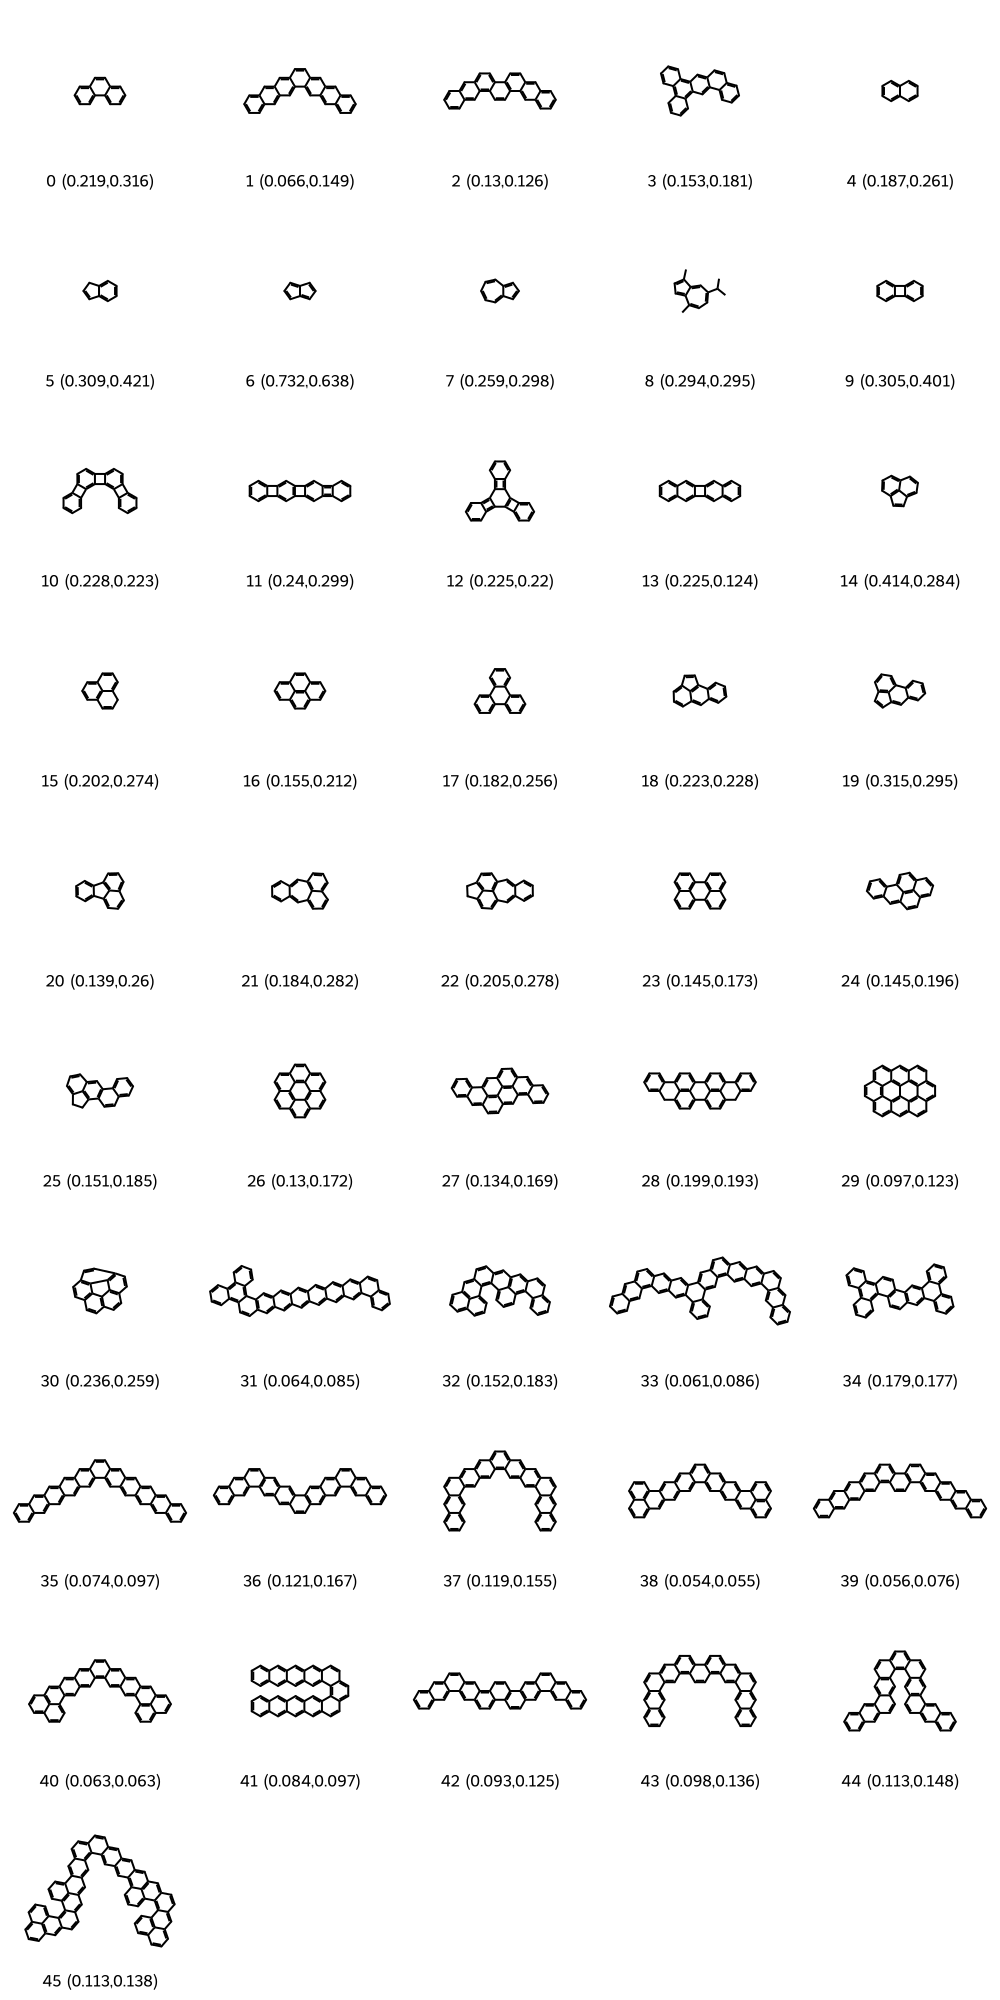

In [208]:
mols = [Chem.MolFromSmiles(s) for s in df_acenes['SMILES'].values]
hre_list = [round(i,3) for i in list(df_acenes['HRE'].values)]
ere_list = [round(i,3) for i in list(df_acenes['ERE'].values)]
labels = [f"{i} ({hre_list[i]},{ere_list[i]})" for i in range(len(df_acenes))]
img = Draw.MolsToGridImage(mols[:50], molsPerRow=5, subImgSize=(200,200), legends=labels)
img

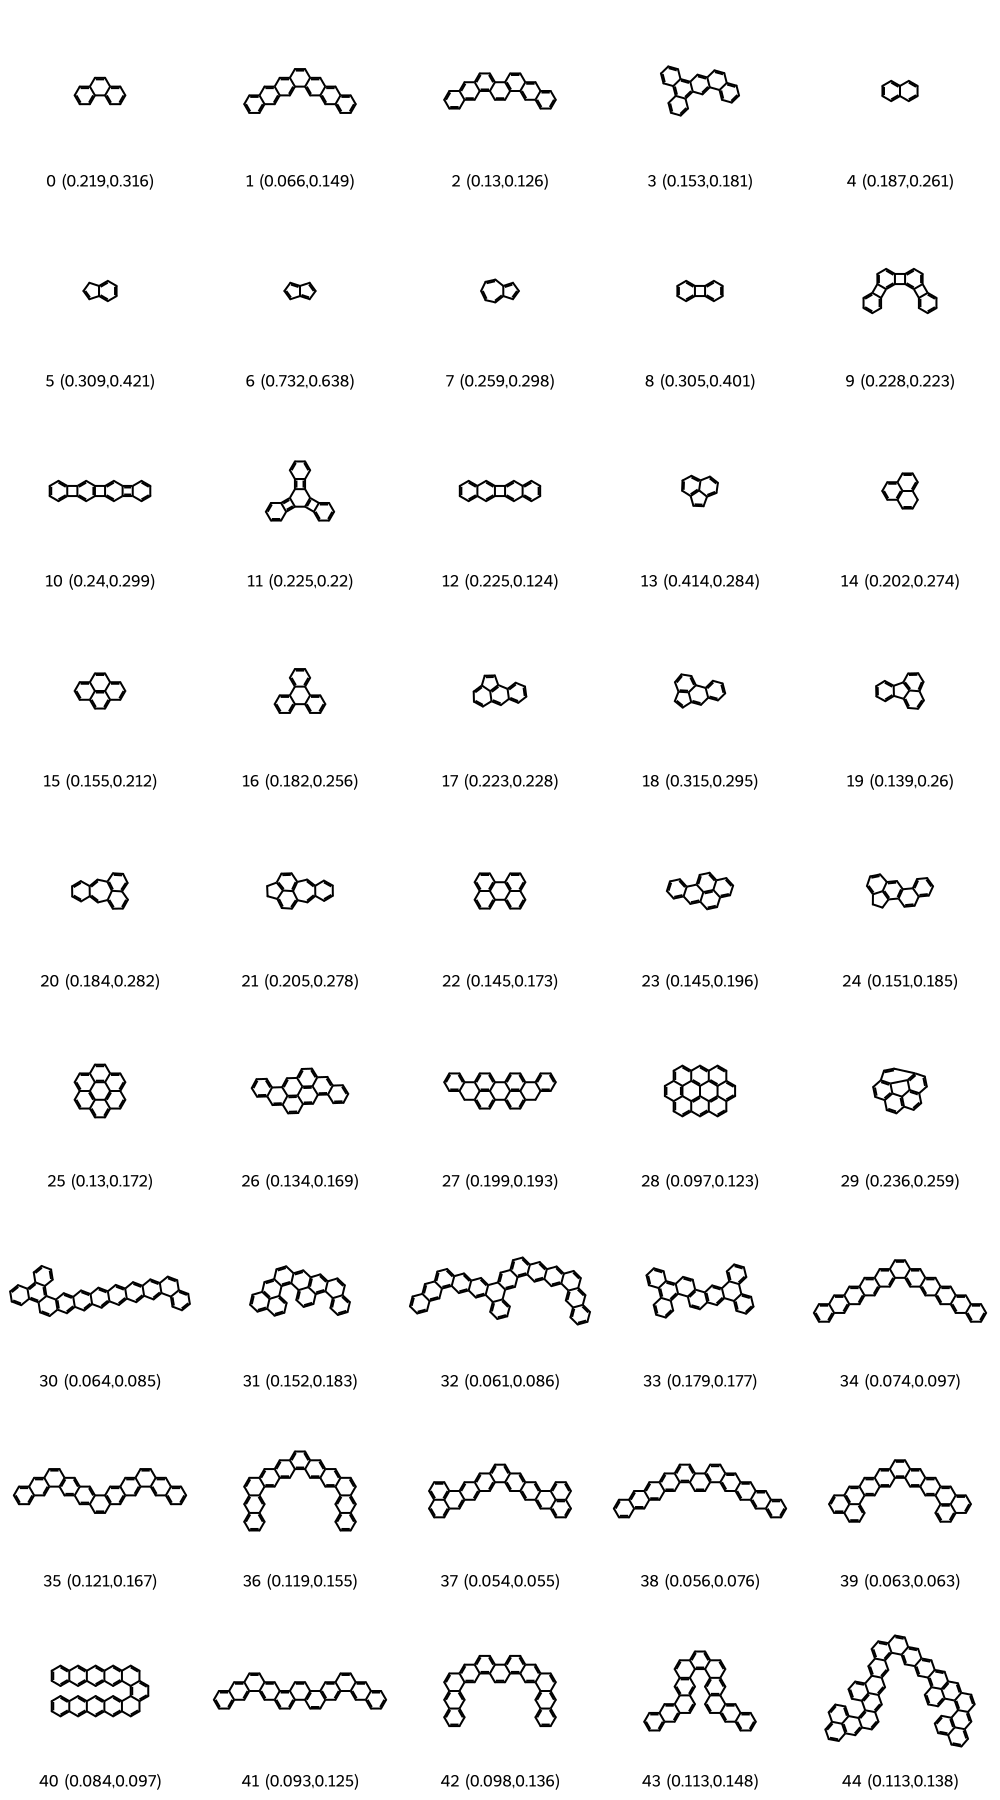

In [209]:
# drop molecule 8
df_acenes = df_acenes.reset_index(drop=True)
df_acenes = df_acenes.drop(8)

mols = [Chem.MolFromSmiles(s) for s in df_acenes['SMILES'].values]
hre_list = [round(i,3) for i in list(df_acenes['HRE'].values)]
ere_list = [round(i,3) for i in list(df_acenes['ERE'].values)]
labels = [f"{i} ({hre_list[i]},{ere_list[i]})" for i in range(len(df_acenes))]
img = Draw.MolsToGridImage(mols[:50], molsPerRow=5, subImgSize=(200,200), legends=labels)
img

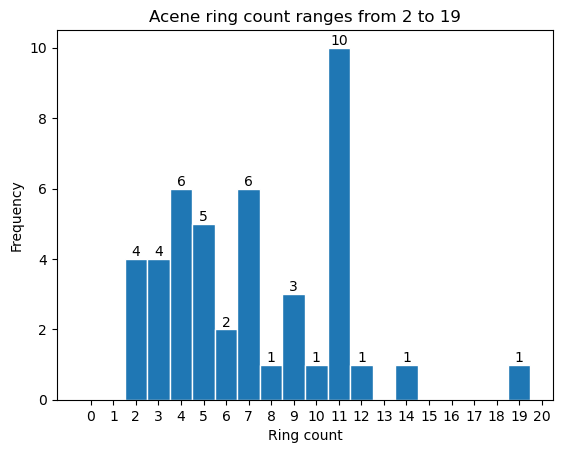

In [146]:
min_val, max_val = int(np.min(df_acenes['rings'])), int(np.max(df_acenes['rings']))
bins = np.arange(0, 21, 1)
ax = df_acenes['rings'].hist(
    grid=False,
    edgecolor='white',
    bins=bins,
    align='left'
)
plt.xlabel('Ring count')
plt.ylabel('Frequency')
plt.title(f'Acene ring count ranges from {min_val} to {max_val}')
plt.xticks(range(0, 21, 1))
for patch in ax.patches:
    height = patch.get_height()
    if height > 0: 
        ax.text(
            patch.get_x() + patch.get_width()/2,   
            height,                             
            str(int(height)),                  
            ha='center', va='bottom'
        )
plt.show()

S-heteroacenes

In [210]:
df_s_hetero = df_s_hetero[(df_s_hetero['bridged'] == 0)]
print(len(df_s_hetero))
mols = [Chem.MolFromSmiles(s) for s in df_s_hetero['SMILES'].values]
hre_list = [round(i,3) for i in list(df_s_hetero['HRE'].values)]
ere_list = [round(i,3) for i in list(df_s_hetero['ERE'].values)]
labels = [f"{i} ({hre_list[i]},{ere_list[i]})" for i in range(len(df_s_hetero))]

140


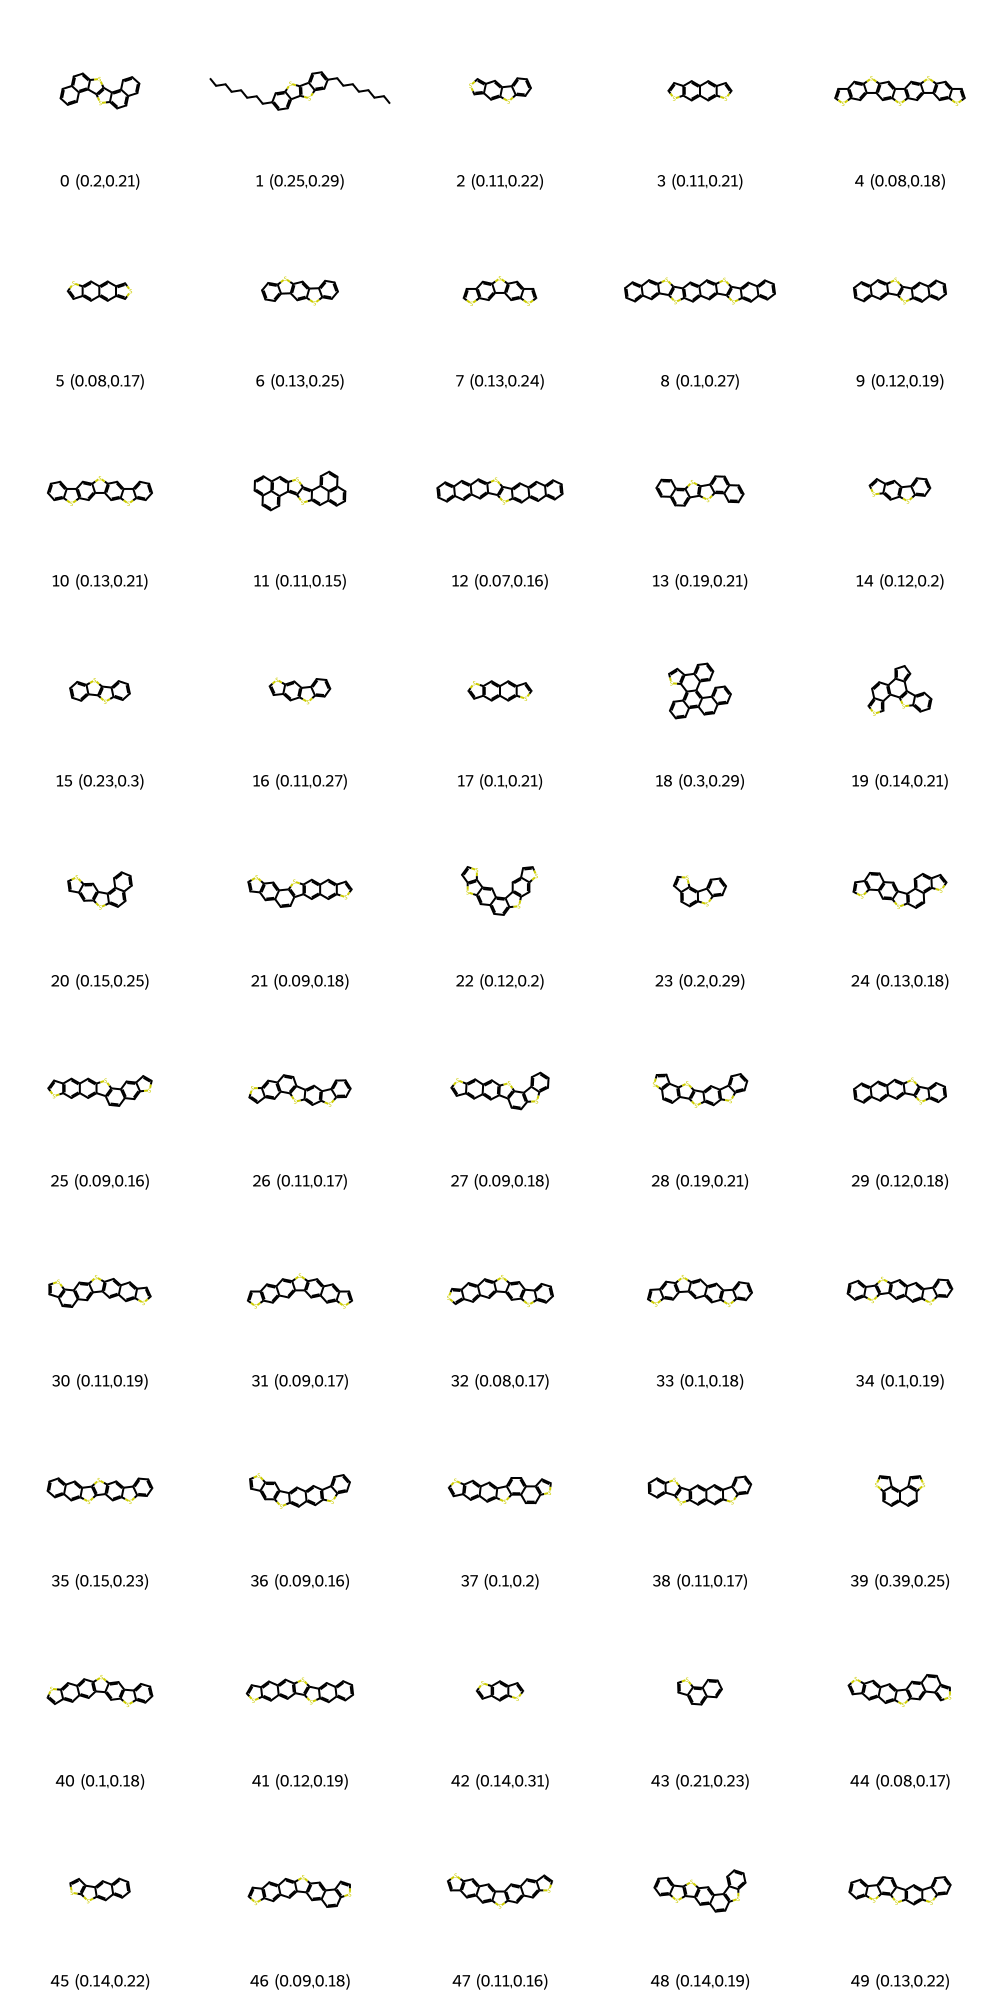

In [188]:
img = Draw.MolsToGridImage(mols[0:50], molsPerRow=5, subImgSize=(200,200), legends=labels[0:50])
img

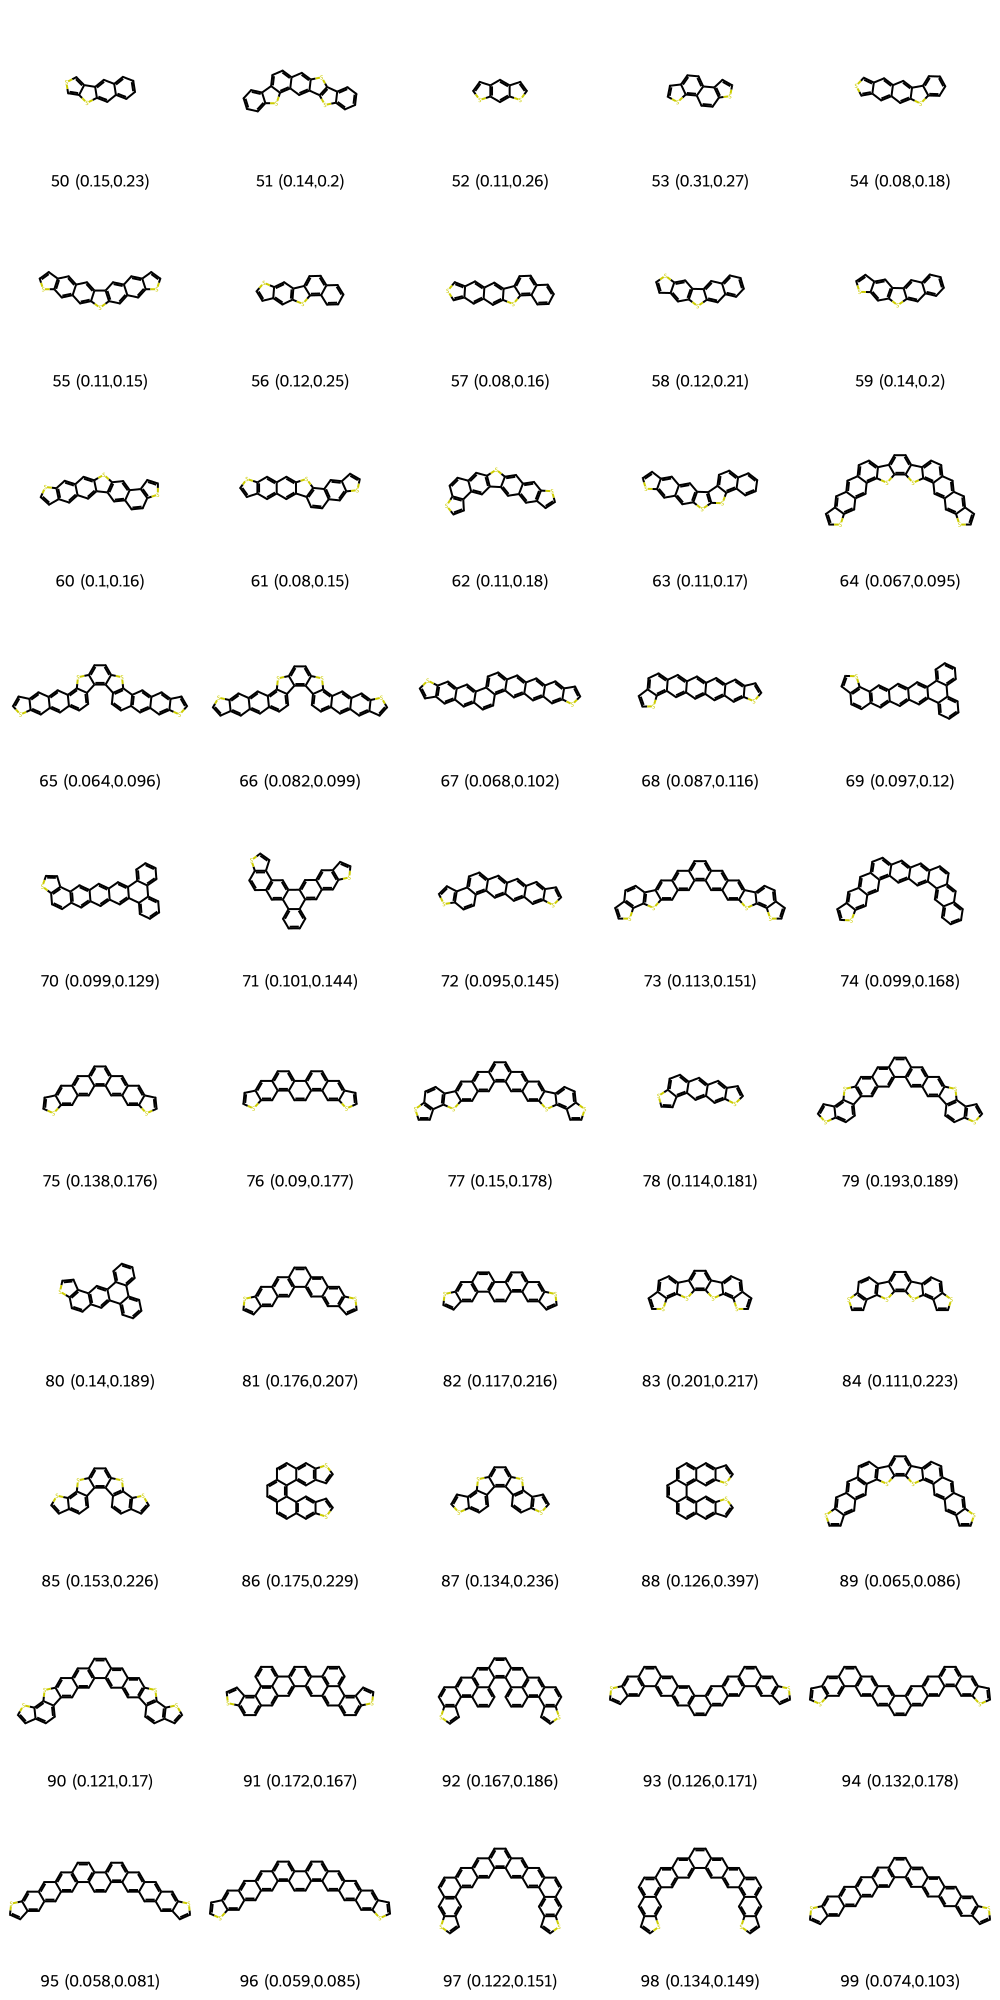

In [189]:
img = Draw.MolsToGridImage(mols[50:100], molsPerRow=5, subImgSize=(200,200), legends=labels[50:100])
img

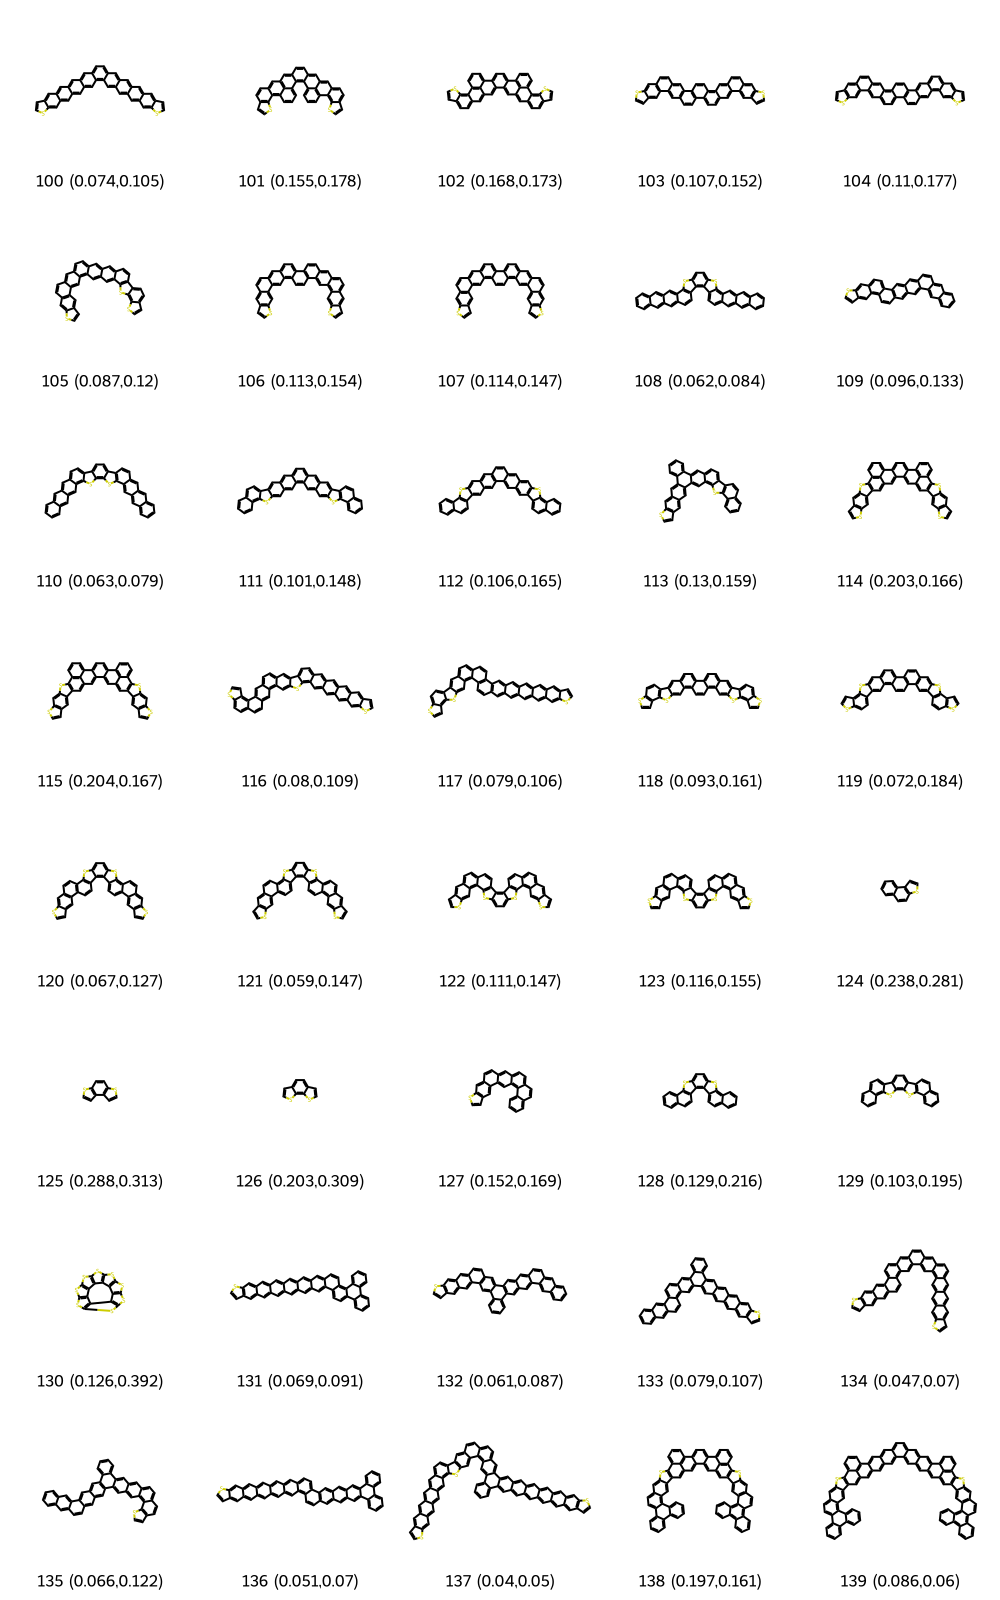

In [190]:
img = Draw.MolsToGridImage(mols[100:], molsPerRow=5, subImgSize=(200,200), legends=labels[100:])
img

In [211]:
# drop molecule 1
df_s_hetero = df_s_hetero.reset_index(drop=True)
df_s_hetero = df_s_hetero.drop(1)

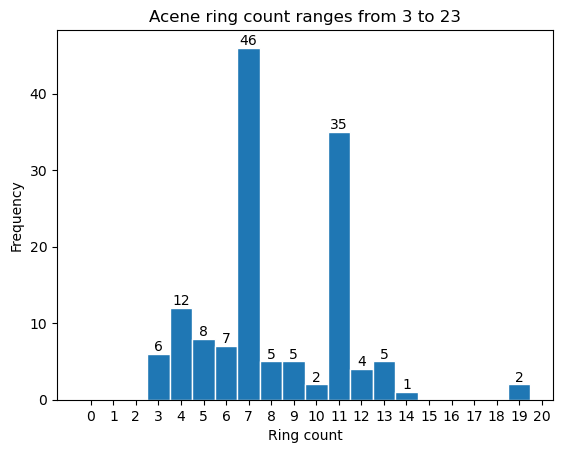

In [212]:
min_val, max_val = int(np.min(df_s_hetero['rings'])), int(np.max(df_s_hetero['rings']))
bins = np.arange(0, 21, 1)
ax = df_s_hetero['rings'].hist(
    grid=False,
    edgecolor='white',
    bins=bins,
    align='left'
)
plt.xlabel('Ring count')
plt.ylabel('Frequency')
plt.title(f'Acene ring count ranges from {min_val} to {max_val}')
plt.xticks(range(0, 21, 1))
for patch in ax.patches:
    height = patch.get_height()
    if height > 0: 
        ax.text(
            patch.get_x() + patch.get_width()/2,   
            height,                             
            str(int(height)),                  
            ha='center', va='bottom'
        )
plt.show()

In [213]:
df_s_hetero.to_csv('mol_datasets/s_hetero.csv')

Stratified sampling by ring count

In [214]:
heteros = []
for ring, num in df_acenes['rings'].value_counts().items():
    subset = df_s_hetero[df_s_hetero['rings'] == ring][:num]
    heteros.append(subset)

df_hetero = pd.concat(heteros, ignore_index=True)


missing = len(df_acenes) - len(df_hetero)
if missing > 0:
    # filter out rows whose SMILES are already in df_hetero
    used_smiles = set(df_hetero['SMILES'])
    unused = df_s_hetero.loc[~df_s_hetero['SMILES'].isin(used_smiles)]
    if len(unused) >= missing:
        extra = unused.sample(n=missing, random_state=42)
    else:
        extra = unused
    df_hetero = pd.concat([df_hetero, extra], ignore_index=True)

print("Target size:", len(df_acenes))
print("Final size:", len(df_hetero))
print("Duplicates present by SMILES?", df_hetero['SMILES'].duplicated().any())

Target size: 45
Final size: 45
Duplicates present by SMILES? False


In [197]:
df_hetero.to_csv('mol_datasets/s_hetero_filtered.csv')

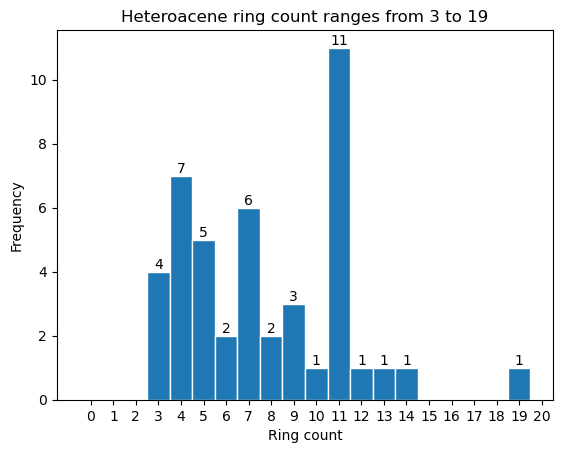

In [199]:
min_val, max_val = int(np.min(df_hetero['rings'])), int(np.max(df_hetero['rings']))
bins = np.arange(0, 21, 1)
ax = df_hetero['rings'].hist(
    grid=False,
    edgecolor='white',
    bins=bins,
    align='left'
)
plt.xlabel('Ring count')
plt.ylabel('Frequency')
plt.title(f'Heteroacene ring count ranges from {min_val} to {max_val}')
plt.xticks(range(0, 21, 1))
for patch in ax.patches:
    height = patch.get_height()
    if height > 0: 
        ax.text(
            patch.get_x() + patch.get_width()/2,   
            height,                             
            str(int(height)),                  
            ha='center', va='bottom'
        )
plt.show()

combine dfs and split it into train & test sets

In [216]:
df_combined = pd.concat([df_acenes, df_hetero], ignore_index=True)
df_combined['Energy'] = (df_combined['HRE'] + df_combined['ERE'])/2
df_combined

,SMILES,ERE,HRE,rings,fused,bridged,F,S,O,Si,N,Energy
0,c1ccc2c(c1)ccc1ccccc12,0.316194,0.218750,3.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.267472
1,c1ccc2cc3cc4c(ccc5cc6cc7ccccc7cc6cc54)cc3cc2c1,0.148908,0.065630,7.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.107269
2,c1ccc2cc3c(ccc4c3ccc3c5cc6ccccc6cc5ccc34)cc2c1,0.125509,0.129530,7.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.127519
3,c1ccc2c(c1)ccc1cc3c4ccccc4c4ccccc4c3cc12,0.180891,0.153495,6.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.167193
4,c1ccc2ccccc2c1,0.260865,0.186561,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.223713
...,...,...,...,...,...,...,...,...,...,...,...,...
85,c1ccc2c(c1)c1ccccc1c1c3cc4c(cc3ccc21)sc1c4cc2c...,0.161182,0.196852,19.0,20.0,0.0,0.0,2.0,0.0,0.0,0.0,0.179017
86,c1cc2cc3cc4cc5cc6ccc7cc8cc9cc%10cc%11ccsc%11cc...,0.104835,0.073711,11.0,10.0,0.0,0.0,2.0,0.0,0.0,0.0,0.089273
87,c1ccc2c(c1)c1ccccc1c1cc3cc4cc5c(ccc6sccc65)cc4...,0.129150,0.099036,8.0,7.0,0.0,0.0,1.0,0.0,0.0,0.0,0.114093
88,c1cc2cc3cc4cc5ccc6cc7ccc8cc9ccc%10c%11cc%12cc%...,0.069836,0.046791,13.0,12.0,0.0,0.0,2.0,0.0,0.0,0.0,0.058313


In [217]:
df_combined[['SMILES', 'Energy']]

,SMILES,Energy
0,c1ccc2c(c1)ccc1ccccc12,0.267472
1,c1ccc2cc3cc4c(ccc5cc6cc7ccccc7cc6cc54)cc3cc2c1,0.107269
2,c1ccc2cc3c(ccc4c3ccc3c5cc6ccccc6cc5ccc34)cc2c1,0.127519
3,c1ccc2c(c1)ccc1cc3c4ccccc4c4ccccc4c3cc12,0.167193
4,c1ccc2ccccc2c1,0.223713
...,...,...
85,c1ccc2c(c1)c1ccccc1c1c3cc4c(cc3ccc21)sc1c4cc2c...,0.179017
86,c1cc2cc3cc4cc5cc6ccc7cc8cc9cc%10cc%11ccsc%11cc...,0.089273
87,c1ccc2c(c1)c1ccccc1c1cc3cc4cc5c(ccc6sccc65)cc4...,0.114093
88,c1cc2cc3cc4cc5ccc6cc7ccc8cc9ccc%10c%11cc%12cc%...,0.058313


In [218]:
df_combined.to_csv('mol_datasets/acene_hetero_merged.csv')